 # Why we need limiters in high-speed flows




 $$

 \frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0

 $$



 Using the **finite volume method**, the semi-discrete form becomes



 $$

 \frac{d\bar{u}_i}{dt}

 =

 -\frac{F_{i+1/2}-F_{i-1/2}}{\Delta x}

 $$



 where the flux is



 $$

 F = cu

 $$



 The key step is reconstructing the **interface value**



 $$

 u_{i+1/2}

 $$


To understand the necessity of limiters, we consider only the spatial reconstruction step. Specifically, we compute the reconstructed value $u_{i+1/2}$ across the function. We shall discuss why we have this extra interpolation step to calculate $u_{i+1/2}$ in FVM in another notebook, when we formally need strict conservation requirment for a problem in high speed flow. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
# ---------------------------------------------------
# Grid
# ---------------------------------------------------

L = 1.0
N = 100

dx = L/N
x = np.linspace(0, L, N, endpoint=False)

# interface locations
x_interface = x + dx/2



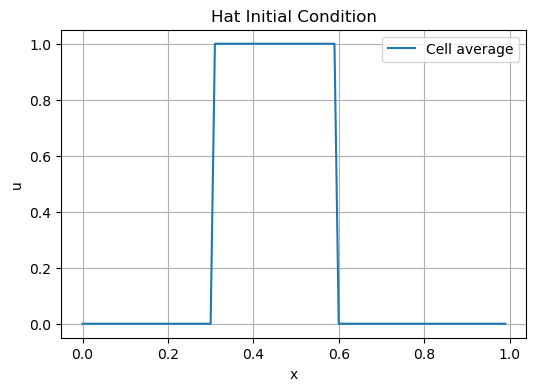

In [3]:
# ---------------------------------------------------
# Hat Initial Condition
# ---------------------------------------------------

def hat(x):

    u = np.zeros_like(x)

    u[(x > 0.3) & (x < 0.6)] = 1.0

    return u


u = hat(x)

plt.figure(figsize=(6,4))
plt.plot(x, u, label="Cell average")
plt.title("Hat Initial Condition")
plt.xlabel("x")
plt.ylabel("u")
plt.grid()
plt.legend()
plt.show()




### First Order Upwind Reconstruction

 $$
 u_{i+1/2} = u_i
 $$

In [ ]:


u_first = u




### Second Order Reconstruction


 $$
 u_{i+1/2}
 =
 u_i + \frac{1}{2}(u_i - u_{i-1})
 $$

In [ ]:


u_second = u + 0.5*(u - np.roll(u,1))




### Third Order Upwind Reconstruction


 $$
 u_{i+1/2} =
 \frac{1}{6}(2u_{i-2}-7u_{i-1}+11u_i)
 $$

In [ ]:


u_third = (2*np.roll(u,2) - 7*np.roll(u,1) + 11*u)/6



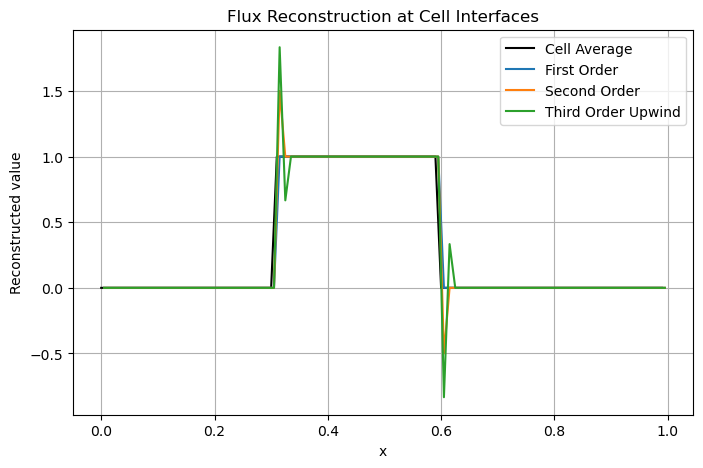

In [7]:
# ---------------------------------------------------
# Plot Reconstructions
# ---------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(x, u, 'k', label="Cell Average")
plt.plot(x_interface, u_first, label="First Order")
plt.plot(x_interface, u_second, label="Second Order")
plt.plot(x_interface, u_third, label="Third Order Upwind")

plt.xlabel("x")
plt.ylabel("Reconstructed value")

plt.title("Flux Reconstruction at Cell Interfaces")

plt.legend()
plt.grid()

plt.show()

In the above plots you can clearly see oscillations in $u_{i+0.5}$ when we use second or third-orders scheme. This is explained by Gudnov-order barrier theorem. To get second-order or higher-order scheme we need limiters. We shall see how to apply this in the next notebook.